# International Football Results Analysis

This notebook answers every question from the assignment document using the provided `results.csv` dataset. Each section shows the code used to produce the answer and a short markdown explanation of the result.


## 1. Load The CSV

The first step is to import pandas and load the match results dataset. I also convert the `date` column to datetime so year-based analysis is accurate.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()


        date home_team away_team  ...     city   country neutral
0 1872-11-30  Scotland   England  ...  Glasgow  Scotland   False
1 1873-03-08   England  Scotland  ...   London   England   False
2 1874-03-07  Scotland   England  ...  Glasgow  Scotland   False
3 1875-03-06   England  Scotland  ...   London   England   False
4 1876-03-04  Scotland   England  ...  Glasgow  Scotland   False

[5 rows x 9 columns]

The preview confirms that the data includes the match date, teams, scores, tournament, city, country, and whether the venue was neutral.


## 2. Basic Exploration


### How many matches are in the dataset?

I use the number of rows in the dataframe because each row represents one match.


In [2]:
df.shape[0]


49071

There are **49,071 matches** in the dataset.


### What is the earliest and latest year in the data?

I extract the year from the `date` column and then take the minimum and maximum values.


In [3]:
earliest_year = df["date"].dt.year.min()
latest_year = df["date"].dt.year.max()
earliest_year, latest_year


(np.int32(1872), np.int32(2026))

The earliest year is **1872** and the latest year is **2026**.


### How many unique countries are there?

The `country` column records where the match was played, so `nunique()` gives the number of distinct countries.


In [4]:
df["country"].nunique()


269

There are **269 unique countries** listed in the dataset.


### Which team appears most frequently as the home team?

I count how often each team appears in the `home_team` column and select the highest value.


In [5]:
df["home_team"].value_counts().head(1)


home_team
Brazil    610
Name: count, dtype: int64

**Brazil** appears most often as the home team, with **610 home matches**.


## 3. Goals Analysis


To analyze scoring patterns, I create a new column called `total_goals` by adding the home and away scores for each match.


In [6]:
df["total_goals"] = df["home_score"] + df["away_score"]
df[["home_score", "away_score", "total_goals"]].head()


   home_score  away_score  total_goals
0           0           0            0
1           4           2            6
2           2           1            3
3           2           2            4
4           3           0            3

### What is the average number of goals per match?

The mean of `total_goals` gives the average goals scored across all matches.


In [7]:
df["total_goals"].mean()


np.float64(2.938456522182144)

The average number of goals per match is **2.94**.


### What is the highest scoring match?

I locate the row where `total_goals` reaches its maximum value.


In [8]:
df.loc[
    df["total_goals"].idxmax(),
    ["date", "home_team", "home_score", "away_score", "away_team", "tournament", "country", "total_goals"],
]


date                    2001-04-11 00:00:00
home_team                         Australia
home_score                               31
away_score                                0
away_team                    American Samoa
tournament     FIFA World Cup qualification
country                           Australia
total_goals                              31
Name: 25420, dtype: object

The highest scoring match was **Australia 31-0 American Samoa** on **2001-04-11**, for a total of **31 goals**.


### Are more goals scored at home or away?

I compare the total of the `home_score` column with the total of the `away_score` column.


In [9]:
home_goals = df["home_score"].sum()
away_goals = df["away_score"].sum()
home_goals, away_goals


(np.int64(86182), np.int64(58011))

More goals are scored at home. Home teams scored **86,182 goals**, while away teams scored **58,011 goals**.


### What is the most common total goals value?

The mode of `total_goals` shows the goal total that appears most often.


In [10]:
df["total_goals"].mode()


0    2
Name: total_goals, dtype: int64

The most common total goals value is **2**.


## 4. Match Results


I classify each match as a `Home Win`, `Away Win`, or `Draw` by comparing the two scores.


In [11]:
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)
df[["home_team", "away_team", "home_score", "away_score", "result"]].head()


  home_team away_team  home_score  away_score    result
0  Scotland   England           0           0      Draw
1   England  Scotland           4           2  Home Win
2  Scotland   England           2           1  Home Win
3   England  Scotland           2           2      Draw
4  Scotland   England           3           0  Home Win

### What percentage of matches are home wins?

I calculate the proportion of `Home Win` outcomes and convert it to a percentage.


In [12]:
result_percentages = df["result"].value_counts(normalize=True).mul(100).round(2)
result_percentages


result
Home Win    49.00
Away Win    28.27
Draw        22.73
Name: proportion, dtype: float64

Home wins make up **49.0%** of all matches.


### Does home advantage exist?

If home teams win much more often than away teams, that suggests a home advantage.


In [13]:
home_win_percentage = result_percentages["Home Win"]
away_win_percentage = result_percentages["Away Win"]
draw_percentage = result_percentages["Draw"]
home_win_percentage, away_win_percentage, draw_percentage


(np.float64(49.0), np.float64(28.27), np.float64(22.73))

Yes, the dataset suggests a home advantage. Home teams win **49.0%** of matches, compared with **28.27%** for away teams, while **22.73%** end in draws.


### Which country has the most wins historically?

A win can come from either the home team or the away team, so I combine both winning team lists and count total wins.


In [14]:
home_team_wins = df.loc[df["home_score"] > df["away_score"], "home_team"]
away_team_wins = df.loc[df["away_score"] > df["home_score"], "away_team"]
all_wins = pd.concat([home_team_wins, away_team_wins])
all_wins.value_counts().head(10)


Brazil         669
England        623
Germany        595
Argentina      586
Sweden         539
South Korea    536
Mexico         510
France         474
Italy          474
Hungary        469
Name: count, dtype: int64

Historically, **Brazil** has the most wins in the dataset with **669 wins**.


## 5. Visualizations


The assignment asks for three visuals: a histogram of goals, a bar chart of match outcomes, and a chart showing the top 10 teams by total wins.


<notebook>:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


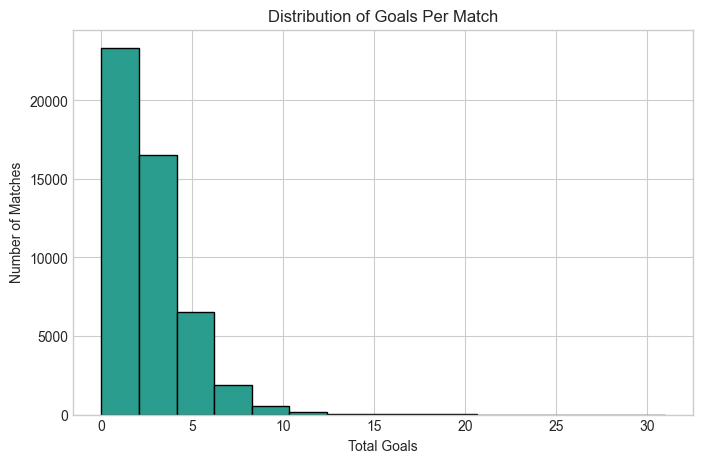

In [15]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
df["total_goals"].hist(bins=15, color="#2a9d8f", edgecolor="black", ax=ax)
ax.set_title("Distribution of Goals Per Match")
ax.set_xlabel("Total Goals")
ax.set_ylabel("Number of Matches")
plt.show()


The histogram shows that low-scoring matches are the most common, with the distribution thinning out as total goals increase.


<notebook>:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


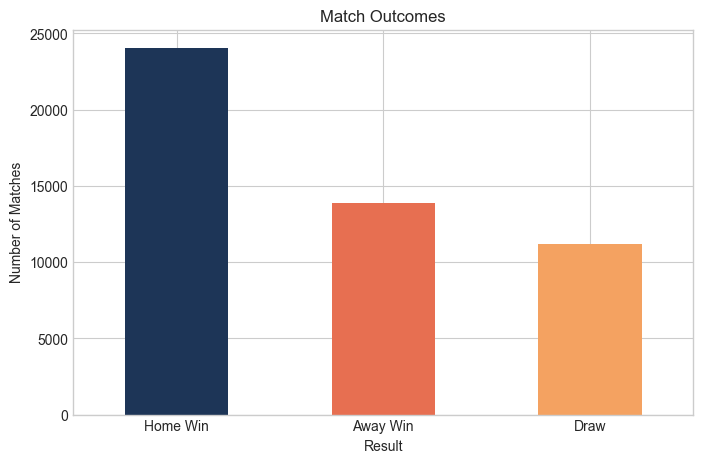

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
df["result"].value_counts().plot(kind="bar", color=["#1d3557", "#e76f51", "#f4a261"], ax=ax)
ax.set_title("Match Outcomes")
ax.set_xlabel("Result")
ax.set_ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.show()


The outcome chart makes the home-win pattern easy to see, which supports the earlier home-advantage conclusion.


<notebook>:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


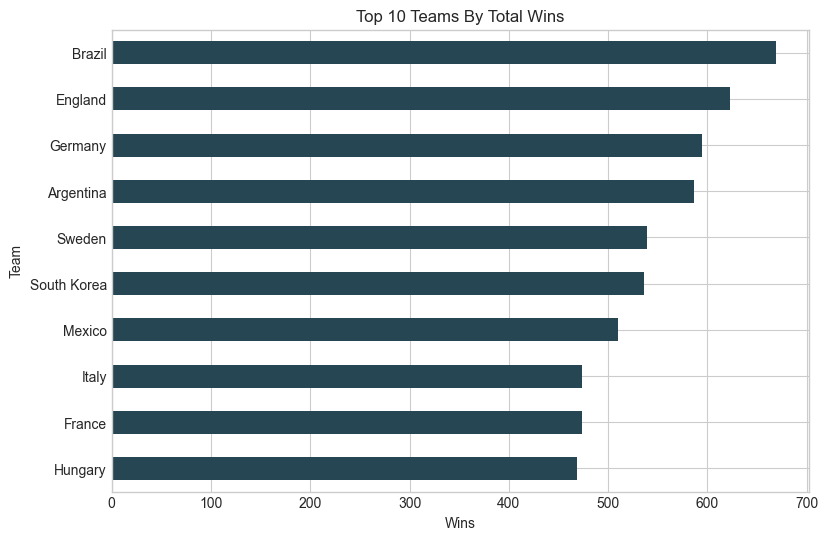

In [17]:
top_10_wins = all_wins.value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_10_wins.plot(kind="barh", color="#264653", ax=ax)
ax.set_title("Top 10 Teams By Total Wins")
ax.set_xlabel("Wins")
ax.set_ylabel("Team")
plt.show()


This chart shows which national teams have accumulated the most historical wins, with Brazil leading the ranking.


## Conclusion

The dataset contains **49,071 matches** spanning **1872 to 2026**. Scoring averages **2.94 goals per match**, home teams score more goals than away teams, and home wins occur more often than away wins. The long-run wins table also shows **Brazil** as the most successful team in this dataset.
